# Recurring Win Profiles in a Pooled Five-Map Valorant Dataset

This notebook is a **classification and clustering** project for the **CSCI 111 Machine Learning Project**.

The main question is:
**In a pooled dataset of `Ascent, Haven, Bind, Icebox, Split`, what recurring win-related profiles appear, and how are they associated with composition flags?**

The notebook now uses **one official D1/D2/D3 workflow** for both classification and clustering so the process matches the class PDF literally.


## PDF and Rubric Alignment

This notebook stays aligned with the class PDF in a rubric-first way:
- the selected dataset is labeled, numeric, and far above the minimum row requirement
- the notebook creates **D1**, **D2**, and **D3** from one official feature set
- it runs exactly **two classification methods** across D1/D2/D3
- it runs **K-Means clustering** across D1/D2/D3 after dropping the label

The official shared feature set keeps the Valorant angle through:
- map context
- each team's ACS-derived carry-shape summaries
- each team's composition flags

That makes the notebook easier to defend academically while still keeping the game-specific interpretation readable.


## Short Valorant Primer

The notebook uses a few game ideas that matter for interpretation:
- **Duelists** usually create entry pressure and take first fights
- **Initiators** gather information and help teammates break into space
- **Controllers** shape the map with smoke and space-control utility
- **Sentinels** anchor sites, guard flanks, and slow down pushes

The comp part of the model is kept through binary flags such as:
- `Double_Duelist`
- `Double_Controller`
- `Double_Sentinel`
- `No_Sentinel`

The continuous carry-shape part comes from ACS-derived summaries:
- **Team StdDev**: how uneven a team's ACS distribution looked on a map
- **Star Gap**: the gap between the highest-ACS and lowest-ACS player on a team

The result is still a machine-learning notebook first, but the interpretation is written so a Valorant viewer can follow what the features mean.


In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler

try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj)

warnings.filterwarnings("ignore", category=ConvergenceWarning)
sns.set_theme(style="whitegrid")

DATASET_PATH = Path("valorant_shared_meta_shape_top5.csv")
TOP_MAP_ORDER = ["Ascent", "Haven", "Bind", "Icebox", "Split"]
MAP_REFERENCE = "Split"
MAP_DUMMY_ORDER = ["Ascent", "Bind", "Haven", "Icebox"]
COMP_FLAG_SUFFIXES = [
    "Double_Duelist",
    "Double_Initiator",
    "Double_Controller",
    "Double_Sentinel",
    "No_Sentinel",
]
label_column = "Team_A_Win"

if not DATASET_PATH.exists():
    raise FileNotFoundError(
        f"Missing {DATASET_PATH.name}. Put this CSV in the same folder as Marino_Code.ipynb before running."
    )

base_df = pd.read_csv(DATASET_PATH)

required_base_columns = [
    "Year",
    "Map",
    label_column,
    "TeamA_Team_StdDev",
    "TeamA_Star_Gap",
    "TeamB_Team_StdDev",
    "TeamB_Star_Gap",
]
for prefix in ["TeamA", "TeamB"]:
    required_base_columns.extend([f"{prefix}_{flag}" for flag in COMP_FLAG_SUFFIXES])

missing_columns = [column for column in required_base_columns if column not in base_df.columns]
if missing_columns:
    raise ValueError(f"The cleaned CSV is missing required columns: {missing_columns}")

base_df = base_df[base_df["Map"].isin(TOP_MAP_ORDER)].copy().reset_index(drop=True)
base_df[label_column] = base_df[label_column].astype(int)

map_volume_summary = (
    base_df["Map"]
    .value_counts()
    .reindex(TOP_MAP_ORDER)
    .fillna(0)
    .astype(int)
    .rename_axis("Map")
    .reset_index(name="Rows")
)
map_volume_summary["Share"] = map_volume_summary["Rows"] / len(base_df)

year_audit = (
    base_df.groupby("Year")
    .size()
    .rename("Rows")
    .reset_index()
    .sort_values("Year")
)
year_audit["Share"] = year_audit["Rows"] / len(base_df)

cleaning_summary = pd.DataFrame(
    [
        {"Check": "Loaded flat cleaned CSV", "Value": DATASET_PATH.name},
        {"Check": "Final cleaned rows", "Value": f"{len(base_df):,}"},
        {"Check": "Retained maps", "Value": ", ".join(TOP_MAP_ORDER)},
        {"Check": "Binary label", "Value": label_column},
        {"Check": "Raw VCT folders required to run this notebook", "Value": "No"},
    ]
)

# Recreate the official 19-input schema directly from the cleaned CSV.
official_df = base_df.copy().reset_index(drop=True)
map_dummy_columns = []
for map_name in MAP_DUMMY_ORDER:
    column_name = f"Map_{map_name}"
    official_df[column_name] = (official_df["Map"] == map_name).astype(int)
    map_dummy_columns.append(column_name)

team_a_features = [
    "TeamA_Team_StdDev",
    "TeamA_Star_Gap",
    "TeamA_Double_Duelist",
    "TeamA_Double_Initiator",
    "TeamA_Double_Controller",
    "TeamA_Double_Sentinel",
    "TeamA_No_Sentinel",
]
team_b_features = [
    "TeamB_Team_StdDev",
    "TeamB_Star_Gap",
    "TeamB_Double_Duelist",
    "TeamB_Double_Initiator",
    "TeamB_Double_Controller",
    "TeamB_Double_Sentinel",
    "TeamB_No_Sentinel",
]
feature_columns = ["Year", *map_dummy_columns, *team_a_features, *team_b_features]
comp_flag_suffixes = COMP_FLAG_SUFFIXES

y = official_df[label_column].copy()

print(f"Loaded {len(base_df):,} clean shared rows from {DATASET_PATH.name}.")
print(f"Five core maps: {', '.join(TOP_MAP_ORDER)}")
print(f"Reference map for dummy encoding: {MAP_REFERENCE}")
print(f"Official shared input count: {len(feature_columns)}")


Built 22,793 clean shared rows and saved them to valorant_shared_meta_shape_top5.csv.
Five core maps: Ascent, Haven, Bind, Icebox, Split
Reference map for dummy encoding: Split
Official shared input count: 19


## Raw-Data Audit and Shared Dataset Construction

Each row in the shared dataset represents one completed professional map and includes:
- the year and map
- both teams' ACS-derived carry-shape summaries
- both teams' composition flags

Keeping only `Side == both` in `overview.csv` is important because those are the full-map player lines. The `attack` and `defend` rows are side splits and would duplicate the same player-map if they were kept.

`First_Kills` is no longer part of the official notebook workflow, so rows are **not** dropped just because that field is missing.


In [2]:
label_count = base_df[label_column].nunique()
row_count = len(base_df)

numeric_base_columns = [
    column for column in base_df.columns
    if column not in {"Map"}
    and pd.api.types.is_numeric_dtype(base_df[column])
]

suitability_summary = pd.DataFrame(
    {
        "Requirement": [
            "Label values between 2 and 5",
            "At least 500 examples",
            "At least 5 numeric columns in the cleaned base dataset",
        ],
        "Observed": [
            label_count,
            row_count,
            len(numeric_base_columns) - 1,
        ],
        "Pass": [
            2 <= label_count <= 5,
            row_count >= 500,
            (len(numeric_base_columns) - 1) >= 5,
        ],
    }
)

print("PDF suitability summary:")
display(suitability_summary)

print("\nCleaning summary:")
display(cleaning_summary)

print("\nYear-by-year usable map counts:")
display(year_audit)

print("\nMap volume in the final shared dataset:")
display(map_volume_summary)

class_balance = (
    base_df[label_column]
    .value_counts()
    .rename_axis("Team_A_Win")
    .reset_index(name="Count")
)
class_balance["Share"] = class_balance["Count"] / class_balance["Count"].sum()

print("\nClass balance:")
display(class_balance.assign(Share=class_balance["Share"].map(lambda value: f"{value:.2%}")))

print("\nShared dataset columns:")
for column in base_df.columns:
    print("-", column)


PDF suitability summary:


,Requirement,Observed,Pass
0,Label values between 2 and 5,2,True
1,At least 500 examples,22793,True
2,At least 5 numeric columns in the cleaned base...,15,True



Cleaning summary:


,Metric,Observed
0,Saved dataset path,valorant_shared_meta_shape_top5.csv
1,Rows in final V4 base dataset,22793
2,Label values,2
3,Null map rows dropped,41
4,Invalid score rows dropped,0
5,Tied score rows dropped,15
6,Comma-agent rows dropped,53
7,Unknown-agent rows dropped,0
8,Invalid ACS rows dropped,355
9,Rows with missing First Kills kept,1564



Year-by-year usable map counts:


...


Map volume in the final shared dataset:


,Map,Count
0,Ascent,5987
1,Haven,5032
2,Bind,4709
3,Icebox,3690
4,Split,3375



Class balance:


,Team_A_Win,Count,Share
0,1,13064,57.32%
1,0,9729,42.68%



Shared dataset columns:
- Year
- Map
- Team_A_Win
- TeamA_Team_StdDev
- TeamA_Star_Gap
- TeamA_Double_Duelist
- TeamA_Double_Initiator
- TeamA_Double_Controller
- TeamA_Double_Sentinel
- TeamA_No_Sentinel
- TeamB_Team_StdDev
- TeamB_Star_Gap
- TeamB_Double_Duelist
- TeamB_Double_Initiator
- TeamB_Double_Controller
- TeamB_Double_Sentinel
- TeamB_No_Sentinel


## Official D1, D2, and D3 Creation

The notebook uses one official feature set for both tasks:
- `Year`
- map dummy columns
- each team's `Team_StdDev` and `Star_Gap`
- each team's comp flags

D1 is the original version of that feature set. D2 and D3 are the MinMax-scaled and Standard-scaled versions.

For classification evaluation, the D2 and D3 models refit their scalers on the **training fold only** so the test fold stays unseen. The full D2 and D3 tables shown here are still useful as the official normalized datasets for the rubric-facing workflow and the clustering section.


In [3]:
D1 = official_df[feature_columns + [label_column]].copy()
D2 = D1.copy()
D3 = D1.copy()

full_minmax_scaler = MinMaxScaler()
full_standard_scaler = StandardScaler()

D2[feature_columns] = full_minmax_scaler.fit_transform(D1[feature_columns])
D3[feature_columns] = full_standard_scaler.fit_transform(D1[feature_columns])

official_datasets = {
    "D1 (Original)": D1,
    "D2 (MinMax)": D2,
    "D3 (Standard)": D3,
}

official_dataset_summary = pd.DataFrame(
    {
        "Dataset": list(official_datasets.keys()),
        "Rows": [len(dataset) for dataset in official_datasets.values()],
        "Columns": [dataset.shape[1] for dataset in official_datasets.values()],
    }
)

print("Official D1/D2/D3 summary:")
display(official_dataset_summary)

print("\nOfficial input columns:")
for column in feature_columns:
    print("-", column)

d2_check = pd.DataFrame({"min": D2[feature_columns].min().round(3), "max": D2[feature_columns].max().round(3)})
d3_check = pd.DataFrame({"mean": D3[feature_columns].mean().round(3), "std": D3[feature_columns].std(ddof=0).round(3)})

print("\nD2 MinMax verification:")
display(d2_check)

print("\nD3 Standard scaling verification:")
display(d3_check)


Official D1/D2/D3 summary:


,Dataset,Rows,Columns
0,D1 (Original),22793,20
1,D2 (MinMax),22793,20
2,D3 (Standard),22793,20



Official input columns:
- Year
- Map_Ascent
- Map_Bind
- Map_Haven
- Map_Icebox
- TeamA_Team_StdDev
- TeamA_Star_Gap
- TeamA_Double_Duelist
- TeamA_Double_Initiator
- TeamA_Double_Controller
- TeamA_Double_Sentinel
- TeamA_No_Sentinel
- TeamB_Team_StdDev
- TeamB_Star_Gap
- TeamB_Double_Duelist
- TeamB_Double_Initiator
- TeamB_Double_Controller
- TeamB_Double_Sentinel
- TeamB_No_Sentinel

D2 MinMax verification:


,min,max
Year,0.0,1.0
Map_Ascent,0.0,1.0
Map_Bind,0.0,1.0
Map_Haven,0.0,1.0
Map_Icebox,0.0,1.0
TeamA_Team_StdDev,0.0,1.0
TeamA_Star_Gap,0.0,1.0
TeamA_Double_Duelist,0.0,1.0
TeamA_Double_Initiator,0.0,1.0
TeamA_Double_Controller,0.0,1.0



D3 Standard scaling verification:


,mean,std
Year,-0.0,1.0
Map_Ascent,0.0,1.0
Map_Bind,0.0,1.0
Map_Haven,0.0,1.0
Map_Icebox,-0.0,1.0
TeamA_Team_StdDev,0.0,1.0
TeamA_Star_Gap,-0.0,1.0
TeamA_Double_Duelist,0.0,1.0
TeamA_Double_Initiator,0.0,1.0
TeamA_Double_Controller,0.0,1.0


## Official Classification Results

The official classifier keeps the classroom setup:
- **Logistic Regression**
- **Random Forest**
- one shared `train_test_split(test_size=0.2, random_state=42, stratify=y)` across all six models

D2 and D3 are evaluated with scalers fit on the training fold only so the reported test metrics avoid scaling leakage.


Shared train/test split summary:


,Train_Rows,Test_Rows,Majority_Class_In_Train,Baseline_Accuracy
0,18234,4559,1,0.5732


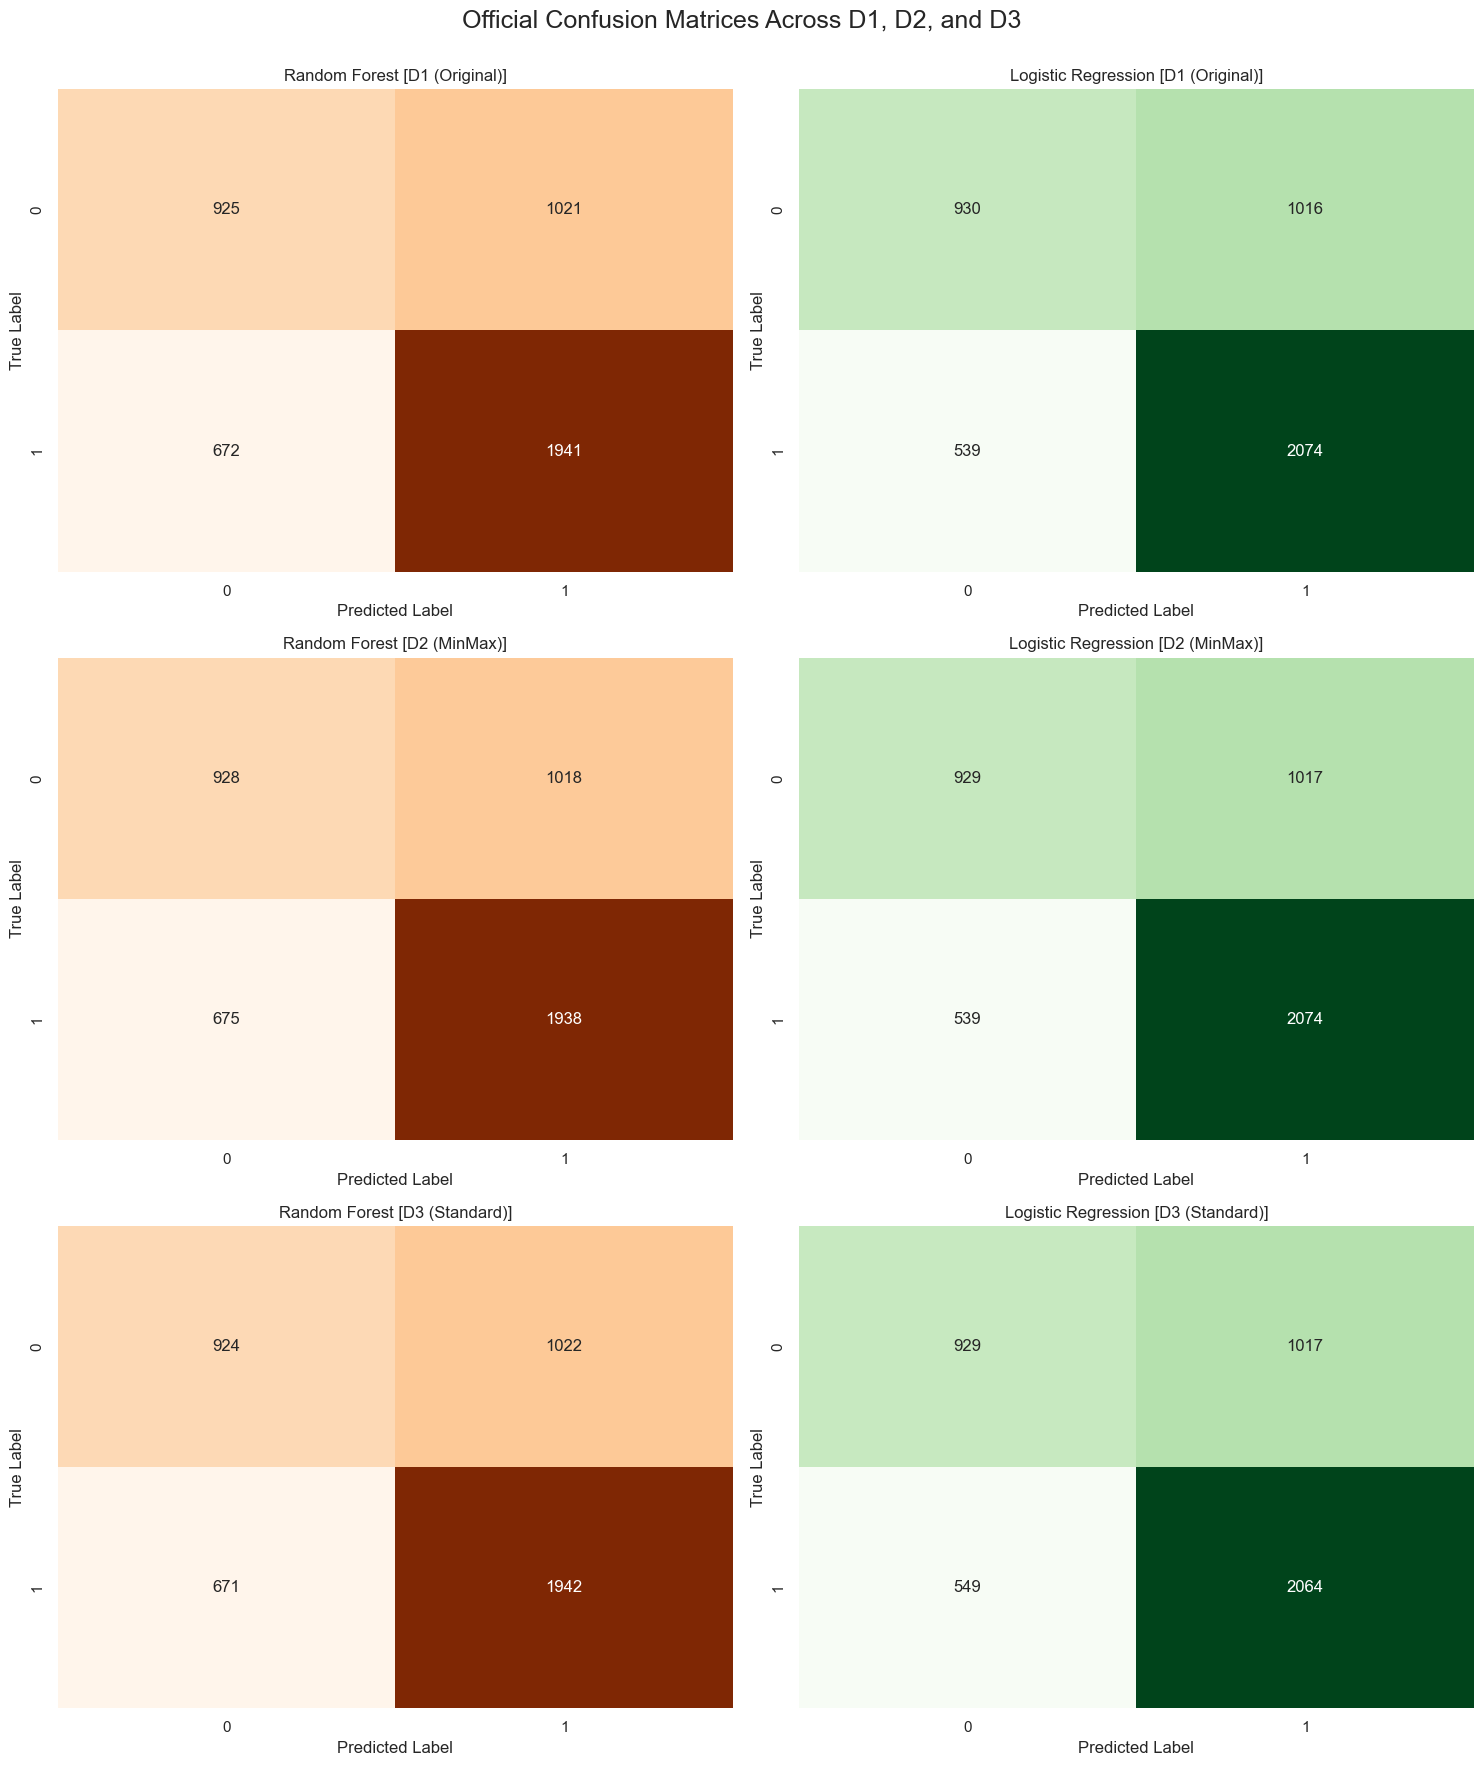

Official six-model summary:


,Dataset,Model,Accuracy,Precision,Recall
0,D1 (Original),Random Forest,0.6286,0.6553,0.7428
1,D1 (Original),Logistic Regression,0.6589,0.6712,0.7937
2,D2 (MinMax),Random Forest,0.6286,0.6556,0.7417
3,D2 (MinMax),Logistic Regression,0.6587,0.6710,0.7937
4,D3 (Standard),Random Forest,0.6286,0.6552,0.7432
5,D3 (Standard),Logistic Regression,0.6565,0.6699,0.7899



Majority-class baseline accuracy: 0.5732


,Dataset,Model,Accuracy,Precision,Recall,Improvement_vs_Baseline
0,D1 (Original),Random Forest,0.6286,0.6553,0.7428,0.0555
1,D1 (Original),Logistic Regression,0.6589,0.6712,0.7937,0.0858
2,D2 (MinMax),Random Forest,0.6286,0.6556,0.7417,0.0555
3,D2 (MinMax),Logistic Regression,0.6587,0.6710,0.7937,0.0855
4,D3 (Standard),Random Forest,0.6286,0.6552,0.7432,0.0555
5,D3 (Standard),Logistic Regression,0.6565,0.6699,0.7899,0.0834
6,Baseline,Majority Class,0.5732,NaN,NaN,0.0000


In [4]:
dataset_order = ["D1 (Original)", "D2 (MinMax)", "D3 (Standard)"]
model_order = ["Random Forest", "Logistic Regression"]
shared_indices = np.arange(len(D1))
train_idx, test_idx = train_test_split(
    shared_indices,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

X_train_raw = D1.iloc[train_idx][feature_columns].reset_index(drop=True)
X_test_raw = D1.iloc[test_idx][feature_columns].reset_index(drop=True)
y_train = y.iloc[train_idx].reset_index(drop=True)
y_test = y.iloc[test_idx].reset_index(drop=True)

majority_class = int(y_train.mode().iloc[0])
majority_baseline_predictions = pd.Series(
    np.full(len(y_test), majority_class),
    index=y_test.index,
)
majority_baseline_accuracy = accuracy_score(y_test, majority_baseline_predictions)

split_summary = pd.DataFrame(
    [
        {
            "Train_Rows": len(train_idx),
            "Test_Rows": len(test_idx),
            "Majority_Class_In_Train": majority_class,
            "Baseline_Accuracy": majority_baseline_accuracy,
        }
    ]
)

print("Shared train/test split summary:")
display(split_summary.round(4))

classification_rows = []
fig, axes = plt.subplots(3, 2, figsize=(15, 18))
fig.suptitle("Official Confusion Matrices Across D1, D2, and D3", fontsize=18)

for row_index, dataset_name in enumerate(dataset_order):
    if dataset_name == "D1 (Original)":
        X_train_model = X_train_raw.copy()
        X_test_model = X_test_raw.copy()
    elif dataset_name == "D2 (MinMax)":
        classification_scaler = MinMaxScaler()
        X_train_model = pd.DataFrame(
            classification_scaler.fit_transform(X_train_raw),
            columns=feature_columns,
        )
        X_test_model = pd.DataFrame(
            classification_scaler.transform(X_test_raw),
            columns=feature_columns,
        )
    else:
        classification_scaler = StandardScaler()
        X_train_model = pd.DataFrame(
            classification_scaler.fit_transform(X_train_raw),
            columns=feature_columns,
        )
        X_test_model = pd.DataFrame(
            classification_scaler.transform(X_test_raw),
            columns=feature_columns,
        )

    models = [
        ("Random Forest", RandomForestClassifier(n_estimators=100, random_state=42), "Oranges"),
        ("Logistic Regression", LogisticRegression(max_iter=3000, random_state=42), "Greens"),
    ]

    for column_index, (model_name, model, cmap) in enumerate(models):
        model.fit(X_train_model, y_train)
        predictions = model.predict(X_test_model)

        classification_rows.append(
            {
                "Dataset": dataset_name,
                "Model": model_name,
                "Accuracy": accuracy_score(y_test, predictions),
                "Precision": precision_score(y_test, predictions),
                "Recall": recall_score(y_test, predictions),
            }
        )

        sns.heatmap(
            confusion_matrix(y_test, predictions),
            annot=True,
            fmt="d",
            cmap=cmap,
            cbar=False,
            ax=axes[row_index, column_index],
        )
        axes[row_index, column_index].set_title(f"{model_name} [{dataset_name}]")
        axes[row_index, column_index].set_xlabel("Predicted Label")
        axes[row_index, column_index].set_ylabel("True Label")

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

classification_summary = pd.DataFrame(classification_rows)
classification_summary["Dataset"] = pd.Categorical(
    classification_summary["Dataset"], categories=dataset_order, ordered=True
)
classification_summary["Model"] = pd.Categorical(
    classification_summary["Model"], categories=model_order, ordered=True
)
classification_summary = classification_summary.sort_values(["Dataset", "Model"]).reset_index(drop=True)

baseline_row = pd.DataFrame(
    [
        {
            "Dataset": "Baseline",
            "Model": "Majority Class",
            "Accuracy": majority_baseline_accuracy,
            "Precision": np.nan,
            "Recall": np.nan,
        }
    ]
)

model_comparison = pd.concat([classification_summary.copy(), baseline_row], ignore_index=True)
model_comparison["Improvement_vs_Baseline"] = model_comparison["Accuracy"] - majority_baseline_accuracy

print("Official six-model summary:")
display(classification_summary.round(4))

print(f"\nMajority-class baseline accuracy: {majority_baseline_accuracy:.4f}")
display(model_comparison.round(4))


In [5]:
logistic_rows = classification_summary[classification_summary["Model"] == "Logistic Regression"].copy()
logistic_rows = logistic_rows.set_index("Dataset")

d1_log_accuracy = logistic_rows.loc["D1 (Original)", "Accuracy"]
d3_log_accuracy = logistic_rows.loc["D3 (Standard)", "Accuracy"]
best_logistic_dataset = logistic_rows["Accuracy"].idxmax()
best_overall_row = classification_summary.sort_values("Accuracy", ascending=False).iloc[0]

if best_overall_row["Model"] == "Logistic Regression":
    if abs(d1_log_accuracy - d3_log_accuracy) <= 0.005:
        recommended_dataset = "D3 (Standard)"
    else:
        recommended_dataset = best_logistic_dataset

    recommended_row = classification_summary[
        (classification_summary["Dataset"] == recommended_dataset)
        & (classification_summary["Model"] == "Logistic Regression")
    ].iloc[0]
else:
    recommended_row = best_overall_row

recommended_model_name = str(recommended_row["Model"])
recommended_dataset_name = str(recommended_row["Dataset"])
improvement_vs_baseline = recommended_row["Accuracy"] - majority_baseline_accuracy

print(
    f"Recommended official classifier: {recommended_model_name} on {recommended_dataset_name} "
    f"(accuracy={recommended_row['Accuracy']:.4f}, "
    f"precision={recommended_row['Precision']:.4f}, "
    f"recall={recommended_row['Recall']:.4f})."
)

print(
    f"Plain-English read: the best official classifier improves on the majority baseline by {improvement_vs_baseline:.4f}. "
    "That means map context, comp flags, and ACS-derived carry-shape variables do contain real signal, but the project still reads more honestly "
    "as a structured review/scouting aid than as a pure pre-match forecasting engine."
)


Recommended official classifier: Logistic Regression on D3 (Standard) (accuracy=0.6565, precision=0.6699, recall=0.7899).
Plain-English read: the best official classifier improves on the majority baseline by 0.0834. That means map context, comp flags, and ACS-derived carry-shape variables do contain real signal, but the project still reads more honestly as a structured review/scouting aid than as a pure pre-match forecasting engine.


## Compact Map-by-Map Comp Tendencies Table

To keep the Valorant meta angle visible without letting the notebook drift into unsupported claims, this section stays descriptive:
- it shows the strongest common comp flag on each map
- it shows the weakest common comp flag on each map

A flag must appear at least **200** team-side times on a map to count as "common" here.


In [6]:
team_side_frames = []
for prefix, win_value in [("TeamA", 1), ("TeamB", 0)]:
    side_df = pd.DataFrame(
        {
            "Map": base_df["Map"],
            "Win": (base_df[label_column] == win_value).astype(int),
        }
    )
    for flag in comp_flag_suffixes:
        side_df[flag] = base_df[f"{prefix}_{flag}"]
    team_side_frames.append(side_df)

team_side_df = pd.concat(team_side_frames, ignore_index=True)
comp_rows = []
for map_name in TOP_MAP_ORDER:
    map_slice = team_side_df[team_side_df["Map"] == map_name]
    flag_summary_rows = []
    for flag in comp_flag_suffixes:
        subset = map_slice[map_slice[flag] == 1]
        flag_summary_rows.append(
            {
                "Flag": flag,
                "Instances": len(subset),
                "Win_Rate": subset["Win"].mean() if len(subset) else np.nan,
            }
        )

    flag_summary = pd.DataFrame(flag_summary_rows)
    flag_summary = flag_summary[flag_summary["Instances"] >= 200].copy()

    if flag_summary.empty:
        comp_rows.append(
            {
                "Map": map_name,
                "Strongest_Common_Flag": np.nan,
                "Strongest_Win_Rate": np.nan,
                "Strongest_Instances": 0,
                "Weakest_Common_Flag": np.nan,
                "Weakest_Win_Rate": np.nan,
                "Weakest_Instances": 0,
            }
        )
        continue

    flag_summary = flag_summary.sort_values(["Win_Rate", "Instances"], ascending=[False, False]).reset_index(drop=True)
    strongest = flag_summary.iloc[0]
    weakest = flag_summary.iloc[-1]

    comp_rows.append(
        {
            "Map": map_name,
            "Strongest_Common_Flag": strongest["Flag"],
            "Strongest_Win_Rate": strongest["Win_Rate"],
            "Strongest_Instances": int(strongest["Instances"]),
            "Weakest_Common_Flag": weakest["Flag"],
            "Weakest_Win_Rate": weakest["Win_Rate"],
            "Weakest_Instances": int(weakest["Instances"]),
        }
    )

comp_tendencies_table = pd.DataFrame(comp_rows)
display(comp_tendencies_table.round(4))


,Map,Strongest_Common_Flag,Strongest_Win_Rate,Strongest_Instances,Weakest_Common_Flag,Weakest_Win_Rate,Weakest_Instances
0,Ascent,Double_Sentinel,0.5452,2067,Double_Duelist,0.4863,4160
1,Haven,Double_Sentinel,0.5179,1008,No_Sentinel,0.4747,316
2,Bind,Double_Controller,0.5274,3544,Double_Sentinel,0.4728,846
3,Icebox,Double_Sentinel,0.5161,3230,Double_Initiator,0.4644,1165
4,Split,Double_Controller,0.5112,1739,Double_Initiator,0.4701,668


In [7]:
print(
    "Plain-English read: this table is descriptive only. It gives a fast coach-style scan of which common comp flags look strongest or weakest on each core map "
    "in this pooled dataset, without claiming that any single flag causes wins by itself."
)


Plain-English read: this table is descriptive only. It gives a fast coach-style scan of which common comp flags look strongest or weakest on each core map in this pooled dataset, without claiming that any single flag causes wins by itself.


## Official Clustering Results on the Same D1/D2/D3 Workflow

K-Means now reuses the **same official D1/D2/D3 feature set** after dropping only the label:
- `k = 2..7` is searched for each dataset
- best `k` is chosen by silhouette score
- ties go to the smaller `k`
- silhouette is computed on a fixed sample of up to **3000 rows** for runtime consistency

The readable scatter uses the official columns `TeamA_Star_Gap` and `TeamB_Star_Gap`, colored by the final cluster labels.


Clustering dataset summary after dropping the label:


,Dataset,Rows,Columns
0,D1 (Original),22793,19
1,D2 (MinMax),22793,19
2,D3 (Standard),22793,19


Observed pooled Team_A_Win baseline: 0.5732
Silhouette search uses a fixed sample of up to 3,000 rows with random_state=42 for runtime consistency.

=== D1 (Original) ===


,K,Silhouette,Inertia
0,2,0.3395,1.156665e+08
1,3,0.3501,7.524195e+07
2,4,0.3243,6.144792e+07
3,5,0.3173,5.112818e+07
4,6,0.3223,4.283475e+07
5,7,0.3198,3.777433e+07


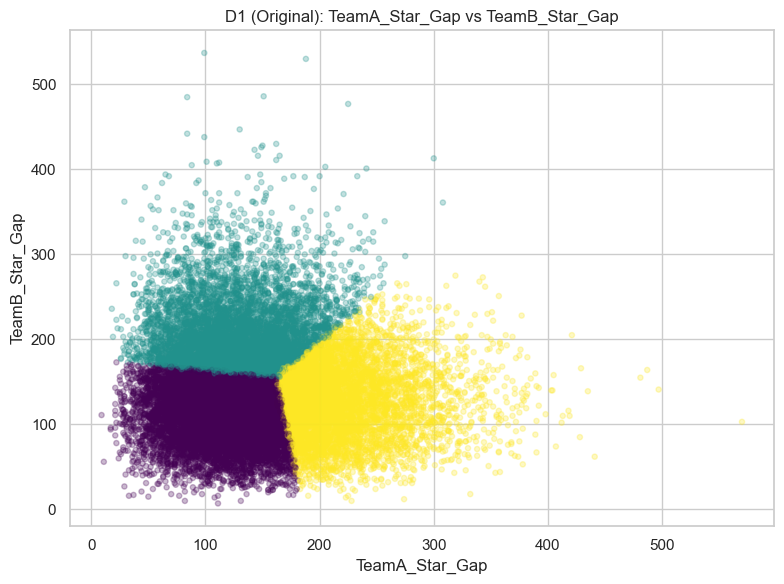

Cluster profile summary:


,Cluster,Count,TeamA_Win_Count,TeamA_Win_Rate,Avg_Star_Gap,Avg_Team_StdDev,Abs_Star_Gap_Diff,Abs_Team_StdDev_Diff,Avg_Double_Duelist,Avg_Double_Initiator,Avg_Double_Controller,Avg_Double_Sentinel,Avg_No_Sentinel,Share,Win_Lift_vs_Overall,Top_Map,Top_Map_Share,Profile_Label
0,0,10228,5880,0.5749,112.5673,41.1876,39.5735,14.5001,0.3694,0.4027,0.1542,0.2247,0.0982,0.4487,0.0017,Ascent,0.2780,Balanced profile
1,1,6164,2327,0.3775,169.5054,61.0495,82.8855,29.1758,0.3971,0.3599,0.1394,0.2494,0.0878,0.2704,-0.1956,Ascent,0.2521,Carry-shaped profile
2,2,6401,4857,0.7588,173.7557,62.6437,93.3684,33.0546,0.4107,0.3527,0.1407,0.2396,0.0917,0.2808,0.1856,Ascent,0.2484,Carry-shaped profile



=== D2 (MinMax) ===


,K,Silhouette,Inertia
0,2,0.1705,47233.7998
1,3,0.1932,41544.5790
2,4,0.2213,36490.9569
3,5,0.2099,34027.4951
4,6,0.2168,31590.2940
5,7,0.2334,29604.6450


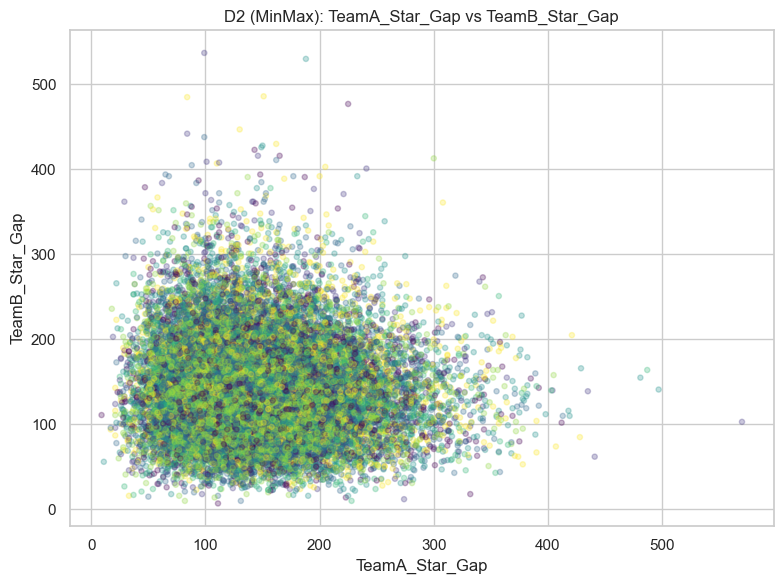

Cluster profile summary:


,Cluster,Count,TeamA_Win_Count,TeamA_Win_Rate,Avg_Star_Gap,Avg_Team_StdDev,Abs_Star_Gap_Diff,Abs_Team_StdDev_Diff,Avg_Double_Duelist,Avg_Double_Initiator,Avg_Double_Controller,Avg_Double_Sentinel,Avg_No_Sentinel,Share,Win_Lift_vs_Overall,Top_Map,Top_Map_Share,Profile_Label
0,0,2305,1309,0.5679,146.0004,52.8364,66.9692,23.8238,0.3727,0.4896,0.0672,0.1241,0.0347,0.1011,-0.0053,Haven,0.3783,Carry-shaped profile
1,1,2509,1468,0.5851,148.8035,53.8775,67.8980,24.2279,0.5343,0.0339,0.1000,0.5821,0.0189,0.1101,0.0119,Split,0.3978,Carry-shaped profile
2,2,3783,2138,0.5652,141.4918,51.3014,65.7232,23.4937,0.0938,0.8010,0.0403,0.1060,0.0287,0.1660,-0.0080,Ascent,0.8729,Lopsided matchup profile
3,3,4672,2794,0.5980,147.2573,53.4290,67.9495,24.2728,0.9486,0.0621,0.0401,0.0281,0.0579,0.2050,0.0249,Ascent,0.2536,Carry-shaped profile
4,4,2605,1516,0.5820,141.1770,51.0495,63.6061,22.7587,0.1248,0.8470,0.0238,0.0411,0.0263,0.1143,0.0088,Haven,1.0000,Lopsided matchup profile
5,5,3019,1673,0.5542,142.3678,51.4916,64.2998,22.8329,0.2425,0.5036,0.7483,0.0202,0.5053,0.1325,-0.0190,Bind,0.8013,Lopsided matchup profile
6,6,3900,2166,0.5554,148.1222,53.7078,67.3562,23.9819,0.2081,0.0856,0.0694,0.7494,0.0082,0.1711,-0.0178,Icebox,0.3885,Carry-shaped profile



=== D3 (Standard) ===


,K,Silhouette,Inertia
0,2,0.2112,381991.0149
1,3,0.1246,342990.4718
2,4,0.1381,317193.9551
3,5,0.1347,299599.2736
4,6,0.1530,286001.7849
5,7,0.1371,274871.1558


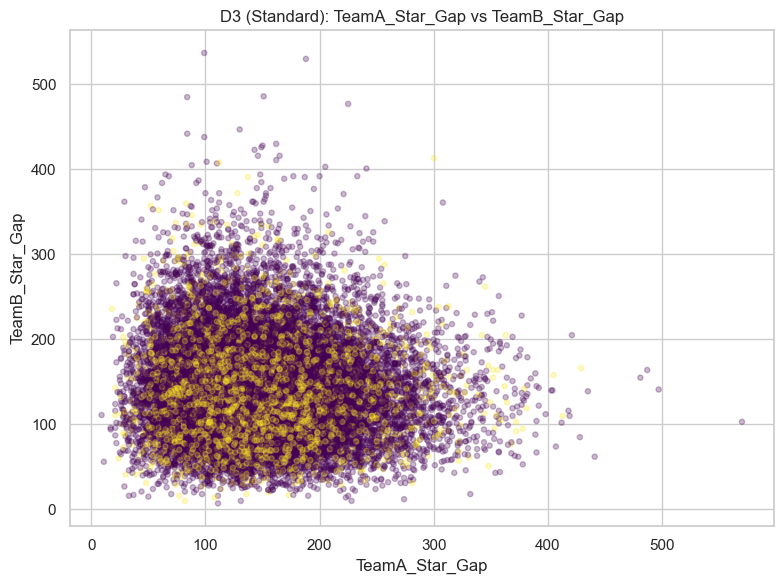

Cluster profile summary:


,Cluster,Count,TeamA_Win_Count,TeamA_Win_Rate,Avg_Star_Gap,Avg_Team_StdDev,Abs_Star_Gap_Diff,Abs_Team_StdDev_Diff,Avg_Double_Duelist,Avg_Double_Initiator,Avg_Double_Controller,Avg_Double_Sentinel,Avg_No_Sentinel,Share,Win_Lift_vs_Overall,Top_Map,Top_Map_Share,Profile_Label
0,0,19082,10967,0.5747,145.5809,52.7469,66.7528,23.8246,0.4029,0.3575,0.0440,0.2730,0.0150,0.8372,0.0016,Ascent,0.3069,Carry-shaped profile
1,1,3711,2097,0.5651,142.9275,51.7493,64.5481,22.9342,0.3142,0.4779,0.6731,0.0434,0.4973,0.1628,-0.0081,Bind,0.7456,Lopsided matchup profile



Best-k clustering summary:


,Dataset,Best_K,Best_Silhouette,Best_Inertia,Highest_Win_Profile,Highest_Cluster_Win_Rate,Lowest_Win_Profile,Lowest_Cluster_Win_Rate,Observed_Profile_Labels
0,D1 (Original),3,0.3501,7.524195e+07,Carry-shaped profile,0.7588,Carry-shaped profile,0.3775,"Carry-shaped profile, Balanced profile"
1,D2 (MinMax),7,0.2334,2.960465e+04,Carry-shaped profile,0.5980,Lopsided matchup profile,0.5542,"Carry-shaped profile, Lopsided matchup profile"
2,D3 (Standard),2,0.2112,3.819910e+05,Carry-shaped profile,0.5747,Lopsided matchup profile,0.5651,"Carry-shaped profile, Lopsided matchup profile"


In [8]:
clustering_datasets = {
    dataset_name: dataset[feature_columns].copy()
    for dataset_name, dataset in official_datasets.items()
}

clustering_summary_table = pd.DataFrame(
    {
        "Dataset": list(clustering_datasets.keys()),
        "Rows": [len(dataset) for dataset in clustering_datasets.values()],
        "Columns": [dataset.shape[1] for dataset in clustering_datasets.values()],
    }
)

print("Clustering dataset summary after dropping the label:")
display(clustering_summary_table)

cluster_base = base_df.copy()
cluster_base["Avg_Star_Gap"] = (cluster_base["TeamA_Star_Gap"] + cluster_base["TeamB_Star_Gap"]) / 2
cluster_base["Avg_Team_StdDev"] = (
    cluster_base["TeamA_Team_StdDev"] + cluster_base["TeamB_Team_StdDev"]
) / 2
cluster_base["Abs_Star_Gap_Diff"] = (
    cluster_base["TeamA_Star_Gap"] - cluster_base["TeamB_Star_Gap"]
).abs()
cluster_base["Abs_Team_StdDev_Diff"] = (
    cluster_base["TeamA_Team_StdDev"] - cluster_base["TeamB_Team_StdDev"]
).abs()

for flag in comp_flag_suffixes:
    cluster_base[f"Avg_{flag}"] = (
        cluster_base[f"TeamA_{flag}"] + cluster_base[f"TeamB_{flag}"]
    ) / 2

overall_profile_means = {
    "Avg_Star_Gap": cluster_base["Avg_Star_Gap"].mean(),
    "Avg_Team_StdDev": cluster_base["Avg_Team_StdDev"].mean(),
}
diff_medians = {
    "Abs_Star_Gap_Diff": cluster_base["Abs_Star_Gap_Diff"].median(),
    "Abs_Team_StdDev_Diff": cluster_base["Abs_Team_StdDev_Diff"].median(),
}
overall_team_a_win_rate = cluster_base[label_column].mean()
profile_label_order = [
    "Carry-shaped profile",
    "Balanced profile",
    "Lopsided matchup profile",
    "Mixed profile",
]

def assign_profile_label(row):
    if (
        row["Avg_Star_Gap"] > overall_profile_means["Avg_Star_Gap"]
        and row["Avg_Team_StdDev"] > overall_profile_means["Avg_Team_StdDev"]
    ):
        return "Carry-shaped profile"
    if (
        row["Avg_Star_Gap"] < overall_profile_means["Avg_Star_Gap"]
        and row["Avg_Team_StdDev"] < overall_profile_means["Avg_Team_StdDev"]
        and row["Abs_Star_Gap_Diff"] < diff_medians["Abs_Star_Gap_Diff"]
        and row["Abs_Team_StdDev_Diff"] < diff_medians["Abs_Team_StdDev_Diff"]
    ):
        return "Balanced profile"
    if (
        row["Abs_Star_Gap_Diff"] > diff_medians["Abs_Star_Gap_Diff"]
        or row["Abs_Team_StdDev_Diff"] > diff_medians["Abs_Team_StdDev_Diff"]
    ):
        return "Lopsided matchup profile"
    return "Mixed profile"

sample_size = min(3000, len(cluster_base))
print(f"Observed pooled Team_A_Win baseline: {overall_team_a_win_rate:.4f}")
print(
    f"Silhouette search uses a fixed sample of up to {sample_size:,} rows with random_state=42 for runtime consistency."
)

best_cluster_rows = []
cluster_profile_tables = {}

for dataset_name, X in clustering_datasets.items():
    search_rows = []
    for k in range(2, 8):
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = km.fit_predict(X)
        search_rows.append(
            {
                "K": k,
                "Silhouette": silhouette_score(X, labels, sample_size=sample_size, random_state=42),
                "Inertia": km.inertia_,
            }
        )

    search_df = pd.DataFrame(search_rows)
    best_row = search_df.sort_values(["Silhouette", "K"], ascending=[False, True]).iloc[0].copy()
    best_k = int(best_row["K"])

    final_kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
    final_labels = final_kmeans.fit_predict(X)

    cluster_view = cluster_base.copy()
    cluster_view["Cluster"] = final_labels

    agg_spec = {
        "Count": ("Cluster", "size"),
        "TeamA_Win_Count": (label_column, "sum"),
        "TeamA_Win_Rate": (label_column, "mean"),
        "Avg_Star_Gap": ("Avg_Star_Gap", "mean"),
        "Avg_Team_StdDev": ("Avg_Team_StdDev", "mean"),
        "Abs_Star_Gap_Diff": ("Abs_Star_Gap_Diff", "mean"),
        "Abs_Team_StdDev_Diff": ("Abs_Team_StdDev_Diff", "mean"),
    }
    for flag in comp_flag_suffixes:
        agg_spec[f"Avg_{flag}"] = (f"Avg_{flag}", "mean")

    cluster_summary = cluster_view.groupby("Cluster").agg(**agg_spec).reset_index()
    cluster_summary["TeamA_Win_Count"] = cluster_summary["TeamA_Win_Count"].astype(int)
    cluster_summary["Share"] = cluster_summary["Count"] / len(cluster_view)
    cluster_summary["Win_Lift_vs_Overall"] = (
        cluster_summary["TeamA_Win_Rate"] - overall_team_a_win_rate
    )

    top_map_rows = []
    for cluster_id, cluster_slice in cluster_view.groupby("Cluster"):
        map_share = cluster_slice["Map"].value_counts(normalize=True)
        top_map_rows.append(
            {
                "Cluster": cluster_id,
                "Top_Map": map_share.index[0],
                "Top_Map_Share": map_share.iloc[0],
            }
        )

    top_map_summary = pd.DataFrame(top_map_rows)
    cluster_summary = cluster_summary.merge(top_map_summary, on="Cluster", how="left")
    cluster_summary["Profile_Label"] = cluster_summary.apply(assign_profile_label, axis=1)
    cluster_profile_tables[dataset_name] = cluster_summary
    highest_win_row = cluster_summary.sort_values(
        ["TeamA_Win_Rate", "Count"], ascending=[False, False]
    ).iloc[0]
    lowest_win_row = cluster_summary.sort_values(
        ["TeamA_Win_Rate", "Count"], ascending=[True, False]
    ).iloc[0]

    observed_labels = [
        label for label in profile_label_order if label in cluster_summary["Profile_Label"].tolist()
    ]
    best_cluster_rows.append(
        {
            "Dataset": dataset_name,
            "Best_K": best_k,
            "Best_Silhouette": best_row["Silhouette"],
            "Best_Inertia": best_row["Inertia"],
            "Highest_Win_Profile": highest_win_row["Profile_Label"],
            "Highest_Cluster_Win_Rate": highest_win_row["TeamA_Win_Rate"],
            "Lowest_Win_Profile": lowest_win_row["Profile_Label"],
            "Lowest_Cluster_Win_Rate": lowest_win_row["TeamA_Win_Rate"],
            "Observed_Profile_Labels": ", ".join(observed_labels),
        }
    )

    print(f"\n=== {dataset_name} ===")
    display(search_df.round(4))

    plt.figure(figsize=(8, 6))
    plt.scatter(
        cluster_base["TeamA_Star_Gap"],
        cluster_base["TeamB_Star_Gap"],
        c=final_labels,
        cmap="viridis",
        alpha=0.28,
        s=14,
    )
    plt.title(f"{dataset_name}: TeamA_Star_Gap vs TeamB_Star_Gap")
    plt.xlabel("TeamA_Star_Gap")
    plt.ylabel("TeamB_Star_Gap")
    plt.tight_layout()
    plt.show()

    print("Cluster profile summary:")
    display(cluster_summary.round(4))

best_cluster_summary = pd.DataFrame(best_cluster_rows)
print("\nBest-k clustering summary:")
display(best_cluster_summary.round(4))


In [9]:
max_abs_win_lift = max(
    summary["Win_Lift_vs_Overall"].abs().max() for summary in cluster_profile_tables.values()
)
if max_abs_win_lift < 0.03:
    lift_read = (
        "The observed lifts are small, so the win association is weak and descriptive rather than causal."
    )
else:
    lift_read = (
        "Some clusters sit meaningfully above or below the pooled baseline, but this remains a post-hoc descriptive read rather than evidence of causation."
    )

print(
    "Plain-English read: K-Means is still unsupervised because Team_A_Win was dropped before fitting. "
    f"The win rates shown in the cluster tables are post-hoc descriptive checks against the pooled Team_A_Win baseline of {overall_team_a_win_rate:.4f}, "
    "so the clusters are being interpreted as above-baseline or below-baseline patterns rather than as proof that a profile causes wins. "
    f"{lift_read}"
)


Plain-English read: K-Means is still unsupervised because Team_A_Win was dropped before fitting. The win rates shown in the cluster tables are post-hoc descriptive checks against the pooled Team_A_Win baseline of 0.5732, so the clusters are being interpreted as above-baseline or below-baseline patterns rather than as proof that a profile causes wins. Some clusters sit meaningfully above or below the pooled baseline, but this remains a post-hoc descriptive read rather than evidence of causation.


## Final Conclusions and Recommendation

The notebook now ends on the pooled main question: **what recurring win-related profiles appear in the shared five-map dataset, and how are they associated with composition flags?**


In [ ]:
def format_label_list(values):
    ordered_unique_values = []
    for value in values:
        if pd.isna(value):
            continue
        value = str(value)
        if value not in ordered_unique_values:
            ordered_unique_values.append(value)

    if not ordered_unique_values:
        return "no labeled profiles"
    if len(ordered_unique_values) == 1:
        return ordered_unique_values[0]
    if len(ordered_unique_values) == 2:
        return " and ".join(ordered_unique_values)
    return ", ".join(ordered_unique_values[:-1]) + f", and {ordered_unique_values[-1]}"

observed_profile_labels_overall = [
    label
    for label in profile_label_order
    if any(label in summary["Profile_Label"].tolist() for summary in cluster_profile_tables.values())
]

if len(observed_profile_labels_overall) == 1:
    observed_label_phrase = observed_profile_labels_overall[0]
elif len(observed_profile_labels_overall) == 2:
    observed_label_phrase = " and ".join(observed_profile_labels_overall)
else:
    observed_label_phrase = ", ".join(observed_profile_labels_overall[:-1]) + f", and {observed_profile_labels_overall[-1]}"

highest_win_profile_values = [
    str(value)
    for value in best_cluster_summary["Highest_Win_Profile"].tolist()
    if pd.notna(value)
]
lowest_win_profile_values = [
    str(value)
    for value in best_cluster_summary["Lowest_Win_Profile"].tolist()
    if pd.notna(value)
]
highest_win_profile_labels = format_label_list(highest_win_profile_values)
lowest_win_profile_labels = format_label_list(lowest_win_profile_values)
overlapping_win_profile_labels = [
    value for value in highest_win_profile_values if value in lowest_win_profile_values
]
overlapping_win_profile_labels = format_label_list(overlapping_win_profile_labels)
max_abs_win_lift = max(
    summary["Win_Lift_vs_Overall"].abs().max() for summary in cluster_profile_tables.values()
)
if max_abs_win_lift < 0.03:
    clustering_strength_read = (
        f"The cluster-level lifts versus the pooled Team_A_Win baseline ({overall_team_a_win_rate:.4f}) stay small, so the win association is weak and descriptive."
    )
else:
    clustering_strength_read = (
        f"Some clusters do sit above or below the pooled Team_A_Win baseline ({overall_team_a_win_rate:.4f}) by a noticeable margin, but the association is still descriptive rather than causal."
    )

if overlapping_win_profile_labels == "no labeled profiles":
    profile_win_read = (
        f"Across the saved D1/D2/D3 clustering outputs, higher-win clusters include {highest_win_profile_labels}, while lower-win clusters include {lowest_win_profile_labels} relative to the pooled Team_A_Win baseline of {overall_team_a_win_rate:.4f}."
    )
else:
    profile_win_read = (
        f"Across the saved D1/D2/D3 clustering outputs, the win-share ordering depends somewhat on scaling: higher-win clusters include {highest_win_profile_labels}, while lower-win clusters include {lowest_win_profile_labels} relative to the pooled Team_A_Win baseline of {overall_team_a_win_rate:.4f}. "
        f"Some profile labels, including {overlapping_win_profile_labels}, appear on both sides of that split across different scaled views."
    )

official_findings = pd.DataFrame(
    {
        "Area": [
            "Dataset suitability",
            "Classification recommendation",
            "Comp tendencies",
            "Clustering",
        ],
        "Finding": [
            f"The shared cleaned dataset contains {row_count:,} rows, a binary label, and well above 5 numeric columns.",
            f"{recommended_model_name} on {recommended_dataset_name} is the recommended official classifier, improving on the majority baseline by {improvement_vs_baseline:.4f}.",
            "Common comp flags still matter descriptively through the map-by-map tendencies table, but the notebook avoids treating any single comp flag as a standalone cause of winning.",
            f"The best-run clustering outputs contain heuristic profiles such as {observed_label_phrase}, and each cluster table now reports whether its observed Team_A_Win share sits above or below the pooled baseline of {overall_team_a_win_rate:.4f}.",
        ],
    }
)

print("Official rubric-facing findings:")
display(official_findings)

print("\nComp tendencies table (final view):")
display(comp_tendencies_table.round(4))

print("\nBest clustering summary (final view):")
display(best_cluster_summary.round(4))

print("\nDirect answer to the main question:")
print(
    f"In this pooled five-map dataset, the recurring win-related patterns are better described as heuristic profiles such as {observed_label_phrase} than as one universal comp recipe. "
    f"{profile_win_read} "
    f"{clustering_strength_read} The classifier still shows that map context, comp flags, and ACS-derived carry-shape variables are associated with match outcomes by a modest but real margin over baseline."
)

print(
    "The descriptive comp table keeps the Valorant meta angle visible, while the clustering section now shows how the same official feature set groups maps into repeatable shapes and how those shapes line up with observed Team_A_Win rates after clustering. "
    "That makes the notebook easier to defend academically and easier to explain to a coach or casual viewer."
)


Official rubric-facing findings:


,Area,Finding
0,Dataset suitability,"The shared cleaned dataset contains 22,793 row..."
1,Classification recommendation,Logistic Regression on D3 (Standard) is the re...
2,Comp tendencies,Common comp flags still matter descriptively t...
3,Clustering,The best-run clustering outputs contain heuris...



Comp tendencies table (final view):


,Map,Strongest_Common_Flag,Strongest_Win_Rate,Strongest_Instances,Weakest_Common_Flag,Weakest_Win_Rate,Weakest_Instances
0,Ascent,Double_Sentinel,0.5452,2067,Double_Duelist,0.4863,4160
1,Haven,Double_Sentinel,0.5179,1008,No_Sentinel,0.4747,316
2,Bind,Double_Controller,0.5274,3544,Double_Sentinel,0.4728,846
3,Icebox,Double_Sentinel,0.5161,3230,Double_Initiator,0.4644,1165
4,Split,Double_Controller,0.5112,1739,Double_Initiator,0.4701,668



Best clustering summary (final view):


,Dataset,Best_K,Best_Silhouette,Best_Inertia,Highest_Win_Profile,Highest_Cluster_Win_Rate,Lowest_Win_Profile,Lowest_Cluster_Win_Rate,Observed_Profile_Labels
0,D1 (Original),3,0.3501,7.524195e+07,Carry-shaped profile,0.7588,Carry-shaped profile,0.3775,"Carry-shaped profile, Balanced profile"
1,D2 (MinMax),7,0.2334,2.960465e+04,Carry-shaped profile,0.5980,Lopsided matchup profile,0.5542,"Carry-shaped profile, Lopsided matchup profile"
2,D3 (Standard),2,0.2112,3.819910e+05,Carry-shaped profile,0.5747,Lopsided matchup profile,0.5651,"Carry-shaped profile, Lopsided matchup profile"



Direct answer to the main question:
In this pooled five-map dataset, the recurring win-related patterns are better described as heuristic profiles such as Carry-shaped profile, Balanced profile, and Lopsided matchup profile than as one universal comp recipe. Across the saved D1/D2/D3 clustering outputs, the win-share ordering depends somewhat on scaling: higher-win clusters include Carry-shaped profile, while lower-win clusters include Carry-shaped profile and Lopsided matchup profile relative to the pooled Team_A_Win baseline of 0.5732. Some profile labels, including Carry-shaped profile, appear on both sides of that split across different scaled views. Some clusters do sit above or below the pooled Team_A_Win baseline (0.5732) by a noticeable margin, but the association is still descriptive rather than causal. The classifier still shows that map context, comp flags, and ACS-derived carry-shape variables are associated with match outcomes by a modest but real margin over baseline.
Th

: 